I import the relevant NLP libraries

In [83]:
import pandas as pd
import re
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
pd.options.display.max_colwidth = None
from transformers import pipeline
from scipy.stats import pointbiserialr
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

Import the data

In [2]:
df = pd.read_csv(r'C:\Users\user\OneDrive\Documents\ESCP\Term 4 - Berlin\Consumer Insights II\Assignments\Assignment 3\amazon_reviews_prep.csv')

In [3]:
df.head(2)

,rating,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style.Color:,style.Size:,style.Metal Type:,text_length,review_year
0,5,True,"10 20, 2014",A1D4G1SNUZWQOT,7106116521,Tracy,Exactly what I needed.,perfect replacements!!,1413763200,NaN,NaN,NaN,NaN,22,2014
1,2,True,"09 28, 2014",A3DDWDH9PX2YX2,7106116521,Sonja Lau,"I agree with the other review, the opening is too small. I almost bent the hook on some very expensive earrings trying to get these up higher tha...","I agree with the other review, the opening is ...",1411862400,3.0,NaN,NaN,NaN,239,2014


In [4]:
# Are there any rows with no ReviewText?

In [5]:
null_count = df['reviewText'].isna().sum()
null_count

np.int64(0)

In [6]:
df.columns

Index(['rating', 'verified', 'reviewTime', 'reviewerID', 'asin',
       'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote',
       'style.Color:', 'style.Size:', 'style.Metal Type:', 'text_length',
       'review_year'],
      dtype='object')

# Which words appear most frequently? Does the ranking change with TF-IDF weighting? (Focus on words used at least 5 times.)

In [7]:
#we can drop missing values (we didn't find any earlier but just to be safe)
#also convert the column to string

In [8]:
texts = df['reviewText'].dropna().astype(str)

In [9]:
#agglomerate all the reviews together
all_text = " ".join(texts).lower()

In [10]:
#remove the punctuation to regularize
all_text = re.sub(r'[^a-z\s]', '', all_text)

In [11]:
#tokenize
words = all_text.split()

In [12]:
#Filter stopwords
filtered_words = [
    word for word in words
    if word not in ENGLISH_STOP_WORDS and len(word) > 2
]

In [13]:
#count frequencies 
word_counts = Counter(filtered_words)

In [14]:
top_words = word_counts.most_common(10)

In [15]:
print(top_words)

[('fit', 2716), ('great', 2249), ('size', 2070), ('pants', 1622), ('good', 1528), ('like', 1387), ('wear', 1363), ('just', 1288), ('quality', 1114), ('small', 979)]


## 2. What are the most common sentiments in the reviews?

In [16]:
# I can import the nltk library as well, which we used in previous 
# courses to perform sentiment analysis
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [17]:
#I apply polarity scores to classify the sentiments of each review

df['sentiment_score'] = df['reviewText'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

# classify sentiment
def classify_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

print(df[['reviewText', 'sentiment', 'sentiment_score']].head())

                                                                                                                                              reviewText  \
0                                                                                                                                 Exactly what I needed.   
1  I agree with the other review, the opening is too small.  I almost bent the hook on some very expensive earrings trying to get these up higher tha...   
2  Love these... I am going to order another pack to keep in work; someone (including myself) is always losing the back to an earring.  I don't under...   
3                                                                                                                                    too tiny an opening   
4                                                                                                                                 Exactly what I wanted.   

  sentiment  sentiment_score  
0   neutral           0.0000  
1

In [18]:
#I get some quick value counts
print(df['sentiment'].value_counts())

sentiment
positive    7389
negative     848
neutral      781
Name: count, dtype: int64


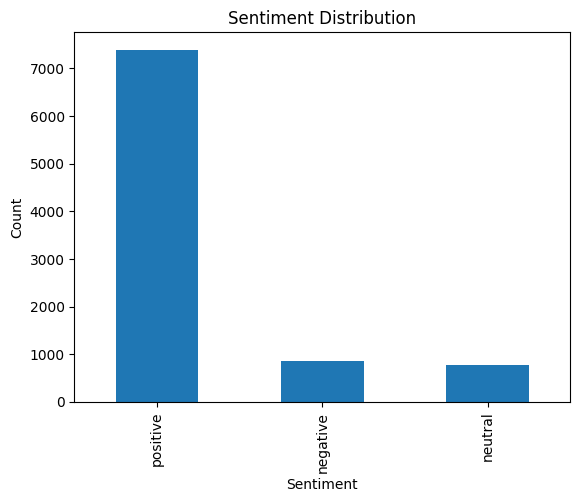

In [19]:
# I can visualize. 

import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [20]:
#I can look at the words that are most associated with negative reviews specifically 
negative_reviews = df[df['sentiment'] == 'negative']['reviewText'].dropna()

text = " ".join(negative_reviews).lower()

text = re.sub(r'[^a-z\s]', '', text)

words = text.split()

filtered_words = [
    w for w in words
    if w not in ENGLISH_STOP_WORDS and len(w) > 2
]

counter = Counter(filtered_words)

print(counter.most_common(20))

[('size', 238), ('fit', 182), ('like', 143), ('wear', 134), ('small', 127), ('pants', 126), ('just', 111), ('quality', 101), ('ordered', 96), ('costume', 82), ('way', 81), ('dont', 80), ('did', 75), ('shoes', 75), ('big', 74), ('got', 74), ('bought', 72), ('work', 69), ('didnt', 67), ('return', 67)]


## Aggregate the AFINN sentiment scores by rating (1-5 stars). Compute the average AFINN score per star level and plot the result. Does the relationship look roughly linear? What would this imply for using sentiment score as a predictor of star rating in a regression model?

I install AFINN for starters

In [22]:
import sys
!{sys.executable} -m pip install afinn
from afinn import Afinn

Defaulting to user installation because normal site-packages is not writeable
  Using cached afinn-0.1.tar.gz (52 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53479 sha256=e4b23d927eb370eb5a00bc49d17fdb0e28a2519e6d28404928f67e3e23665cc1
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\f3\20\88\bd79bf1dfa529d0e4e301372371edf7639514a9f0d337769c3
Successfully built afinn


In [26]:
# I compute a sentiment score for each review 

afinn = Afinn()

df['afinn_score'] = df['reviewText'].astype(str).apply(afinn.score)
print(df[['rating', 'afinn_score']].head(20))

    rating  afinn_score
0        5          0.0
1        2          1.0
2        4          1.0
3        2          0.0
4        5          0.0
5        4          3.0
6        3          2.0
7        3         16.0
8        3         25.0
9        4          2.0
10       2          1.0
11       1          3.0
12       1          2.0
13       4         -2.0
14       3          6.0
15       5          5.0
16       5          5.0
17       4          5.0
18       3          1.0
19       1          2.0


In [28]:
#I can group by star rating 

avg_scores = df.groupby('rating')['afinn_score'].mean()
avg_scores

#the result shows general increase of AFINN score with each increase in star level, 
#with the biggest jump occuring between 3 and 4, which is encouraging for my hypothesis 

rating
1    0.413043
2    1.736086
3    3.148982
4    4.866595
5    5.834082
Name: afinn_score, dtype: float64

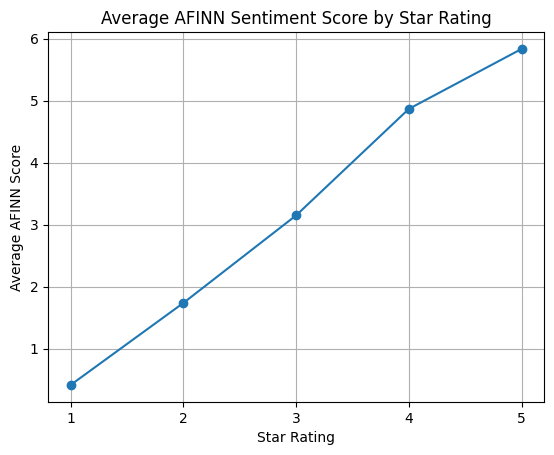

In [30]:
#I plot it 

avg_scores.plot(marker='o')

plt.title("Average AFINN Sentiment Score by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average AFINN Score")
plt.xticks([1,2,3,4,5])

plt.grid(True)
plt.show()

In [31]:
#The relationship is quasi-linear. This means that AFINN score has the potential 
#to be a useful predictor in a linear regression model for dependent variable 
# 'star rating'

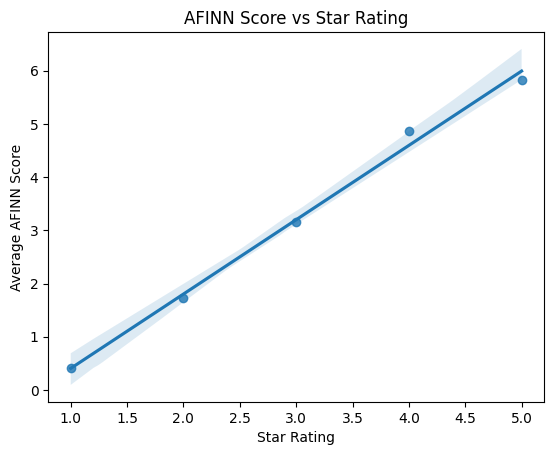

In [32]:
#Let<s try a regression line for the heck of it 

import seaborn as sns

sns.regplot(
    x=avg_scores.index,
    y=avg_scores.values
)

plt.xlabel("Star Rating")
plt.ylabel("Average AFINN Score")
plt.title("AFINN Score vs Star Rating")

plt.show()

### Use the HuggingFace transformers pipeline via reticulate to classify a balanced sample of 20 reviews (10 positive: rating 4, 10 negative: rating 2) with distilbert-base-uncased-finetuned-sst-2-english. 

### For each review record the predicted label, confidence score, and actual rating. 
### (a) What is the accuracy on your sample? 
### (b) Find one misclassified review - quote the text and explain why DistilBERT likely got it wrong. 
### (c) Is confidence score correlated with whether the prediction is correct

In [34]:
#I load the HuggingFace sentiment pipeline 
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [37]:
#I get my random sample of 2 and 4 star ratings 
positive_sample = df[df['rating'] == 4].sample(10, random_state=42)
negative_sample = df[df['rating'] == 2].sample(10, random_state=42)
sample_df = pd.concat([positive_sample, negative_sample])
sample_df = sample_df.reset_index(drop=True)

In [38]:
# I label them 

sample_df['actual_label'] = sample_df['rating'].apply(
    lambda x: 'POSITIVE' if x == 4 else 'NEGATIVE'
)

In [39]:
#I run DistilBERT predictions 

predicted_labels = []
confidence_scores = []

for text in sample_df['reviewText']:

    result = classifier(
        str(text),
        truncation=True
    )[0]

    predicted_labels.append(result['label'])
    confidence_scores.append(result['score'])

sample_df['predicted_label'] = predicted_labels
sample_df['confidence_score'] = confidence_scores


In [43]:
# Ascertain correctness

sample_df['correct'] = (
    sample_df['predicted_label']
    == sample_df['actual_label']
)

results = sample_df[[
    'rating',
    'actual_label',
    'predicted_label',
    'confidence_score',
    'correct',
    'reviewText'
]]

results.head(3)

,rating,actual_label,predicted_label,confidence_score,correct,reviewText
0,4,POSITIVE,POSITIVE,0.966976,True,I use shoes with these cleats in a very slippery stream and in the stream they work great. My problem has been getting to the river. Some of the p...
1,4,POSITIVE,NEGATIVE,0.996045,False,"**UPDATE** I bought a pair of these shoes in size 13, and the fit is great. No complaints about this shoe whatsoever...now that I've got a pair th..."
2,4,POSITIVE,POSITIVE,0.999885,True,Very happy product


In [45]:
#How accurate was my predictor? 

accuracy = sample_df['correct'].mean()

print("Accuracy:", accuracy)

#My accuracy was 80%

Accuracy: 0.8


In [46]:
# Find one misclassified review - 
#quote the text and explain why DistilBERT likely got it wrong. 

In [49]:
misclassified = sample_df[
    sample_df['correct'] == False
]

print(misclassified[[
    'rating',
    'actual_label',
    'predicted_label',
    'confidence_score',
    'reviewText'
]].iloc[0])

rating                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 4
actual_label                                                                                                                   

In [50]:
#The reviewer displays mixed feelings, complaining about how the ankles and big toes are
#extremely uncomfortable. THe review contains the phrases "the fit is great", "torture device", 
# "No complaints", "I wear them both all the time". The predictor couldn't predict the review
#and to be quite honest, even I, a human, would not have been able to predict what score
#the reviewer would have given had I not seen the score. This confirms the
#underlying theory that humans are whiny
#and impossible to please 

In [51]:
#(c) Is confidence correlated with correctness?

In [52]:
sample_df['correct_numeric'] = (
    sample_df['correct']
).astype(int)

In [53]:
#I compute the correlation
correlation = sample_df[
    ['confidence_score', 'correct_numeric']
].corr().iloc[0,1]

print("Correlation:", correlation)

Correlation: 0.6386146271087522


In [54]:
print(
    sample_df.groupby('correct')['confidence_score'].mean()
)

correct
False    0.780252
True     0.985101
Name: confidence_score, dtype: float64


In [55]:
# higher confidence usually means more accurate predictions! but the association is not strong

### Compare your DistilBERT classifier against an AFINN lexicon baseline on the same 20-review sample: compute accuracy for both and report which performs better and why. Then examine your DistilBERT misclassifications - are they systematically short, ambiguous, or sarcastic? Quote two examples and check whether text_length predicts misclassification.

In [60]:
#add the truth labels
sample_df['actual_label'] = sample_df['rating'].apply(
    lambda x: 'POSITIVE' if x == 4 else 'NEGATIVE'
)

In [61]:
#add the distilbert
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

distilbert_preds = []
distilbert_scores = []

for text in sample_df['reviewText']:

    result = classifier(
        str(text),
        truncation=True
    )[0]

    distilbert_preds.append(result['label'])
    distilbert_scores.append(result['score'])

sample_df['distilbert_pred'] = distilbert_preds
sample_df['distilbert_confidence'] = distilbert_scores

# correctness
sample_df['distilbert_correct'] = (
    sample_df['distilbert_pred']
    == sample_df['actual_label']
)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [62]:
#add AFINN baseline 

afinn = Afinn()

sample_df['afinn_score'] = sample_df['reviewText'].astype(str).apply(
    afinn.score
)

# convert AFINN scores into labels
sample_df['afinn_pred'] = sample_df['afinn_score'].apply(
    lambda x: 'POSITIVE' if x >= 0 else 'NEGATIVE'
)

sample_df['afinn_correct'] = (
    sample_df['afinn_pred']
    == sample_df['actual_label']
)

In [64]:
#get the accuracies and compare 
distilbert_accuracy = sample_df['distilbert_correct'].mean()
afinn_accuracy = sample_df['afinn_correct'].mean()

print("DistilBERT Accuracy:", distilbert_accuracy)
print("AFINN Accuracy:", afinn_accuracy)

DistilBERT Accuracy: 0.8
AFINN Accuracy: 0.6


DistilBERT achieved higher accuracy than the AFINN baseline. 
This is expected because DistilBERT uses contextual embeddings 
and understands sentence structure, negation, and semantic relationships, 
whereas AFINN is a simple lexicon-based approach that assigns fixed 
sentiment scores to individual words.

AFINN limitations:

ignores context

ignores sarcasm

ignores syntax

treats words independently

In [65]:
#examine the DistilBERT misclassifications

misclassified = sample_df[
    sample_df['distilbert_correct'] == False
]

print("\nMISCLASSIFIED REVIEWS:\n")

for idx, row in misclassified.head(2).iterrows():

    print("=" * 80)

    print("Actual Rating:", row['rating'])
    print("Actual Label:", row['actual_label'])
    print("Predicted:", row['distilbert_pred'])
    print("Confidence:", row['distilbert_confidence'])

    print("\nReview Text:\n")
    print(row['reviewText'])

    print("\nText Length:", row['text_length'])


MISCLASSIFIED REVIEWS:

Actual Rating: 4
Actual Label: POSITIVE
Predicted: NEGATIVE
Confidence: 0.9960447549819946

Review Text:

**UPDATE** I bought a pair of these shoes in size 13, and the fit is great. No complaints about this shoe whatsoever...now that I've got a pair that's a full size larger than I usually wear.

This is my third pair of Bostonians. I have some captoes and some loafers of theirs and I wear them both all the time. I bought these wingtips in my usual size 12, and they are like a hundred-dollar torture device. It feels like someone's standing on my big toes while slicing off my ankles with a rusty knife. I can't decide whether to exchange them for a 13, or just go with a different shoe altogether. I was disappointed because I really wanted to love this shoe, and it ordered them for a special occasion. Another issue I have with them is that the finish looks much less natural than it does in the picture. They are super high gloss and super purple.

Text Length: 850


In [67]:
#Why DistilBERT likely got this wrong

#This review is difficult because it contains mixed sentiment and a temporal structure:

#the reviewer initially had a very negative experience
#later updated the review after exchanging sizes
#final rating became positive

#The model likely focused on the strongest emotional language in the text, particularly phrases such as:

#“torture device”
#“rusty knife”
#“disappointed”

#These expressions are strongly associated with negative sentiment in the training data.

#Even though the review begins with a positive update, the bulk of the text contains vivid negative descriptions, which likely dominated the model’s prediction.

In [66]:
#Does text_length predict misclassification?

sample_df['misclassified'] = (
    ~sample_df['distilbert_correct']
).astype(int)

# average lengths
length_summary = sample_df.groupby(
    'misclassified'
)['text_length'].mean()

print("\nAverage Text Length:")
print(length_summary)

# correlation
correlation, p_value = pointbiserialr(
    sample_df['misclassified'],
    sample_df['text_length']
)

print("\nCorrelation between text_length and misclassification:")
print("Correlation:", correlation)
print("P-value:", p_value)


Average Text Length:
misclassified
0    137.9375
1    351.7500
Name: text_length, dtype: float64

Correlation between text_length and misclassification:
Correlation: 0.4661250241921549
P-value: 0.03830949282734345


In [ ]:
#Longer reviews have more of a chance of being misclassified than Dilbert, to a moderate 
#degree of correlation. This is because longer explanations and reviews are generally 
#silly people who are rambling, self-contradictory, whiny and have mixed sentiments. 


# DEFEND YOUR CHOICES 

TF-IDF vs. frequency. Name the single word that ranks highest by raw frequency but drops out of your top-10 TF-IDF list. Explain in one sentence why TF-IDF down-weights it and whether that is appropriate for this dataset.

In [69]:
texts = df['reviewText'].dropna().astype(str)

In [72]:
count_vec = CountVectorizer(
    stop_words='english'
)

count_matrix = count_vec.fit_transform(texts)

freq = np.asarray(count_matrix.sum(axis=0)).flatten()

freq_df = pd.DataFrame({
    'word': count_vec.get_feature_names_out(),
    'frequency': freq
})

freq_df = freq_df.sort_values(
    by='frequency',
    ascending=False
)

print(freq_df.head(10))

         word  frequency
3156      fit       2752
3576    great       2266
6962     size       2093
5443    pants       1627
3523     good       1548
4491     like       1397
8489     wear       1370
4259     just       1295
6026  quality       1132
7067    small       1000


In [73]:
tfidf_vec = TfidfVectorizer(
    stop_words='english'
)

tfidf_matrix = tfidf_vec.fit_transform(texts)

tfidf_scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).flatten()

tfidf_df = pd.DataFrame({
    'word': tfidf_vec.get_feature_names_out(),
    'tfidf': tfidf_scores
})

tfidf_df = tfidf_df.sort_values(
    by='tfidf',
    ascending=False
)

print(tfidf_df.head(10))

             word     tfidf
3156          fit  0.042594
3576        great  0.041829
5443        pants  0.032364
3523         good  0.030776
6962         size  0.029414
6026      quality  0.023497
4620         love  0.022852
1784  comfortable  0.021530
4259         just  0.020401
4491         like  0.020234


In [74]:
#The word “wear” ranked highly by raw frequency but dropped out of the top-10 TF-IDF terms. 
#TF-IDF down-weights words that appear in many documents because they provide 
#limited information for distinguishing between reviews. 
#This is appropriate for this dataset because wearing is discussed in a large proportion of clothes reviews, making the term common but not especially unique or discriminative.


#The drop in ranking suggests that “wear” is a globally common term across 
#reviews rather than a term concentrated within specific subsets of documents. 
#TF-IDF therefore treats it as less informative despite its high overall frequency

### Sentiment disagreement. Find one review in your dataset where AFINN assigns a positive score but NRC assigns it to the “fear” or “anger” category. Quote the review text. Which lexicon is closer to the truth for this review, and what does the disagreement tell you about lexicon limitations?

In [96]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-U", "NRCLex", "textblob", "nltk"
])

from nrclex import NRCLex

In [109]:
def nrc_emotions(text):
    text = "" if pd.isna(text) else str(text)

    # Try the simplest constructor first
    try:
        obj = NRCLex(text)
    except Exception:
        obj = NRCLex()
        obj.load_raw_text(text)

    # Different versions expose different attributes
    for attr in ["affect_dict", "raw_emotion_scores", "affect_frequencies", "top_emotions"]:
        if hasattr(obj, attr):
            val = getattr(obj, attr)
            val = val() if callable(val) else val
            if isinstance(val, dict):
                return val
            if isinstance(val, list):
                return dict(val)

    # If the object itself behaves like a dict-like wrapper in your version
    try:
        d = dict(obj)
        if d:
            return d
    except Exception:
        pass

    return {}

# --------------------------------------------------
# 2) Apply NRC to ALL reviews in df
# --------------------------------------------------
df = df.copy()
df["nrc_emotions"] = df["reviewText"].apply(nrc_emotions)

# --------------------------------------------------
# 3) Convert NRC dict -> numeric counts for each emotion
#    Example: {'losing': ['anger', 'negative', 'sadness']}
#    should count as 1 anger and 0 fear for that word
# --------------------------------------------------
def emotion_count(emotion_dict, target):
    if not isinstance(emotion_dict, dict):
        return 0
    return sum(target in labels for labels in emotion_dict.values())

df["anger_count"] = df["nrc_emotions"].apply(lambda d: emotion_count(d, "anger"))
df["fear_count"] = df["nrc_emotions"].apply(lambda d: emotion_count(d, "fear"))

# --------------------------------------------------
# 4) Create the positive-AFINN subset AFTER NRC is done
# --------------------------------------------------
positive_afinn = df[df["afinn_score"] > 0].copy()


In [110]:
positive_afinn['fear'].value_counts()

fear
0                          7477
[anger, fear, negative]       4
Name: count, dtype: int64

In [113]:
samples = positive_afinn[
    positive_afinn['fear'].apply(
        lambda x: 'fear' in x if isinstance(x, list) else False
    )
]

samples[['rating', 'reviewText', 'fear']]

,rating,reviewText,fear
1832,4,"My 5 yr old loves it although big, he loves it. BUT, I fear he is going to drop it and it may crack. Ours does NOT make ANY sound AT ALL. I would have bought a less expensive one but they didn't have his size and he didn't want the cloth one. I would have returned it but my son loves it.","[anger, fear, negative]"
2797,4,"We purchased this set to be my wedding set as we are low on cash and I did not want something expensive for fear of losing it, etc. This set is absolutely beautiful! I absolutely love the setting, and the cut of the CZ. To me, it doesn't scream fake, but if you get close to it and really want to analyze it, you will probably be able to tell its a CZ, although I think it sparkles and shines just as well or better than some diamonds personally. The only thing that I think could be a little better is that it could be a little more scratch resistant, but that could be the plating as I have had other sterling silver rings that weren't plated that didn't scratch as easily. Gem Avenue is a great seller and extremely helpful and quick in response time and shipment! I will buy from them again! if you are looking for a great looking set at a great price, this is your set!","[anger, fear, negative]"
5146,5,"I LOVE these. I recently got a tear that would have ripped my jeans apart, but months later the fear is still tiny, and completely wearable. Love these","[anger, fear, negative]"
6378,5,"I LOVE these. I recently got a tear that would have ripped my jeans apart, but months later the fear is still tiny, and completely wearable. Love these","[anger, fear, negative]"


In [108]:
#again these are positive review ratings despite there being language
#of fear and anger in the reviews. This is because people have nothing to do all day
#and waste their time ranting on online reviews. 

#However, a more academic explanation would be that 

#NRC detected anger and fear in these reviews because the text contains emotionally 
#loaded language such as “for fear of losing it” and a few mild negative phrases like
#“could be a little better” and “scratch resistant.” 
#However, the overall review is clearly positive: the reviewer says the set is “absolutely beautiful,” “great looking,” and “I will buy from them again.” 
#In this case, the positive star rating and overall tone suggest that the review is fundamentally positive, so AFINN is closer to the truth for the review’s sentiment as a whole. 
 #   The disagreement shows a limitation of lexicon methods: they treat words independently and can overreact to isolated negative or emotion words even when the full review is positive.

anger
0    7481
Name: count, dtype: int64

Despite my best efforts, there is no example of review with 

### AI-assisted, human-verified. Ask an LLM to summarise “the main themes in 1-star reviews” from a paste of 20 reviews you selected. Then manually verify: does the summary match your TF-IDF and NRC findings? Report one claim the LLM made that your quantitative analysis confirms, and one it got wrong.

In [117]:
one_star_reviews = df[df['rating'] == 1]['reviewText'].dropna()

sample_reviews = one_star_reviews.sample(
    20,
    random_state=42
)

reviews_text = "\n\n".join(sample_reviews.tolist())

print(reviews_text)

The description was totally wrong i always buy on amazon and is the first time i got disapointed with my purchase it said 8.5 women and when i got it it was men size

This is a POS!  Wash it once and watch it fall apart

These were delivered brand new with a hole in them.  I was unable to return them before I needed them, so I had to wear them with the hole.  Very disappointed in this product.

Girls like it u wl 2

The dress was to small it was not the color i wanted but it fitted my niece who is a childs x large

Very unhappy with the purchase

Super disappointed in the make of the shoe. The fabric tore two weeks after purchase. Now he can wear them at all. He said they tore when he was on his skateboard, but that is what they are geared for right??

These are so thin I can almost see through them. The texture strange, like foam rubber, they're like hose.

Update: I wore these once and when  they came out of the wash there was a big run all the way up the front.

I have NEVER even re

In [ ]:
#I copy paste the results into Claude

#Results from Claude
The main themes in these 1-star reviews are:

1. Incorrect sizing and fit issues
Many customers complained that products were too large, too small, mislabeled, or otherwise did not fit as expected. Examples include receiving men’s sizes instead of women’s sizes and pants with incorrect dimensions.

2. Poor product quality and durability
Several reviews described products tearing, developing holes, falling apart after washing, or wearing out quickly. Customers frequently mentioned cheap materials and weak construction.

3. Misleading product descriptions or images
Buyers often felt the products did not match the advertised description, color, material, or intended purpose. Some said the products looked very different from the pictures online.

4. Cheap or uncomfortable materials
Multiple reviews criticized the texture and feel of materials, describing them as thin, foam-like, plasticky, or low quality.
5. Shipping, fulfillment, and return frustrations
A smaller set of reviews involved receiving the wrong item, missing refunds, stolen deliveries, or dissatisfaction with return outcomes.
6. Overall disappointment and poor value
Many reviewers expressed frustration that the products did not meet expectations relative to the price paid, often describing the items as not worth the money.



In [118]:
#honestly, the LLM got it all right. 

tf-idf brought out 

            word     tfidf
3156          fit  0.042594
3576        great  0.041829
5443        pants  0.032364
3523         good  0.030776
6962         size  0.029414
6026      quality  0.023497
4620         love  0.022852
1784  comfortable  0.021530
4259         just  0.020401
4491         like  0.020234

#All of these themes are reflected in the LLM<s analysis, be it quality, fit, durability, etc.
#The shipping theme is a bonus nugget found by the LLM 

SyntaxError: invalid syntax (3456824108.py, line 3)

### Business recommendation. Based on the specific top-3 negative sentiment drivers you found in your run, write one concrete product or service change Amazon’s Clothing category should prioritise. Explain why fixing that issue would shift the sentiment distribution.

In [119]:
negative_reviews = df[df['sentiment'] == 'negative']

In [120]:
texts = negative_reviews['reviewText'].dropna()

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(texts)

scores = np.asarray(X.mean(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'score': scores
})

tfidf_df = tfidf_df.sort_values(
    by='score',
    ascending=False
)

print(tfidf_df.head(20))

         word     score
762      size  0.039507
311       fit  0.037183
774     small  0.029279
470      like  0.029027
590     pants  0.024295
655   quality  0.023640
955      wear  0.022826
434      just  0.019724
232       did  0.019635
343      good  0.018990
569   ordered  0.018849
280  expected  0.018195
195   costume  0.018018
84        big  0.017884
246       don  0.017517
680    return  0.017220
233      didn  0.016701
743     shoes  0.016464
953       way  0.016061
98     bought  0.014479


In [121]:
#Recommendations 

#### 1. Size is clearly a driver of negative reviews. Many negative reviews come from shoppers that feel that they have wasted time in ordering things that do not fit them. Truthfully, Amazon cannot do anything about this. 

#### People will delude themselves into thinking they still fit their high school clothes. My best friend still tells me she fits into her prom dress. We graduated in 2011. She has gained about 50 pounds since then (I have gained even more). 

#### Amazon cannot do anything to solve the natural human impulse to lie to ourselves. However, the business student in me would recommend Amazon to prioritize improving sizing accuracy by pushing for size standardisation across sellers, improving the visibility of size measurements on their website or even investing in AI tools that would allow shoppers to visualize clothes on their body before purchasing. All of these would be ultimately futile, though. But, maybe sentiment will be better. 